# Arbitrage index

Given the reference trade sizes, price the executable cross-pool round trip and
summarize it into a per-pool-pair arbitrage index. Parameters come from
`arblib.config.STUDY`.

In [1]:
from arblib import data_io, analysis, sizing, arbitrage, modeling, plotting
from arblib.config import STUDY as S

pools = data_io.load_processed_pools(S.processed_dir)
analysis.add_mid_price(pools)

x_usd = data_io.load_price_series(S.x_price_path)
y_usd = data_io.load_price_series(S.y_price_path)
price0, price1 = sizing.constant_usd_prices(x_usd, y_usd)

quantiles = data_io.load_quantiles(S.quantiles_path)
print(quantiles)

/Users/matthieu/Downloads/DeFi_limits-to-arbitrage/arblib/data_io.py:108: DtypeWarning: Columns (6) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(path, skipinitialspace=True)
/Users/matthieu/Downloads/DeFi_limits-to-arbitrage/arblib/data_io.py:108: DtypeWarning: Columns (6) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(path, skipinitialspace=True)
/Users/matthieu/Downloads/DeFi_limits-to-arbitrage/arblib/data_io.py:108: DtypeWarning: Columns (3) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(path, skipinitialspace=True)


Loaded 8 processed pools: ['uniswap_1', 'uniswap_2', 'uniswap_3', 'uniswap_4', 'uniswap_5', 'uniswap_6', 'pancake_1', 'pancake_2']
quantile
0.2      25.305772
0.4      98.297823
0.6     381.251111
0.8    2552.089436
Name: usd, dtype: float64


## 1. Cross-DEX mid-price gaps

The raw opportunity before execution costs: per-pool mid prices and the absolute
price difference for every cross-DEX pool pair.

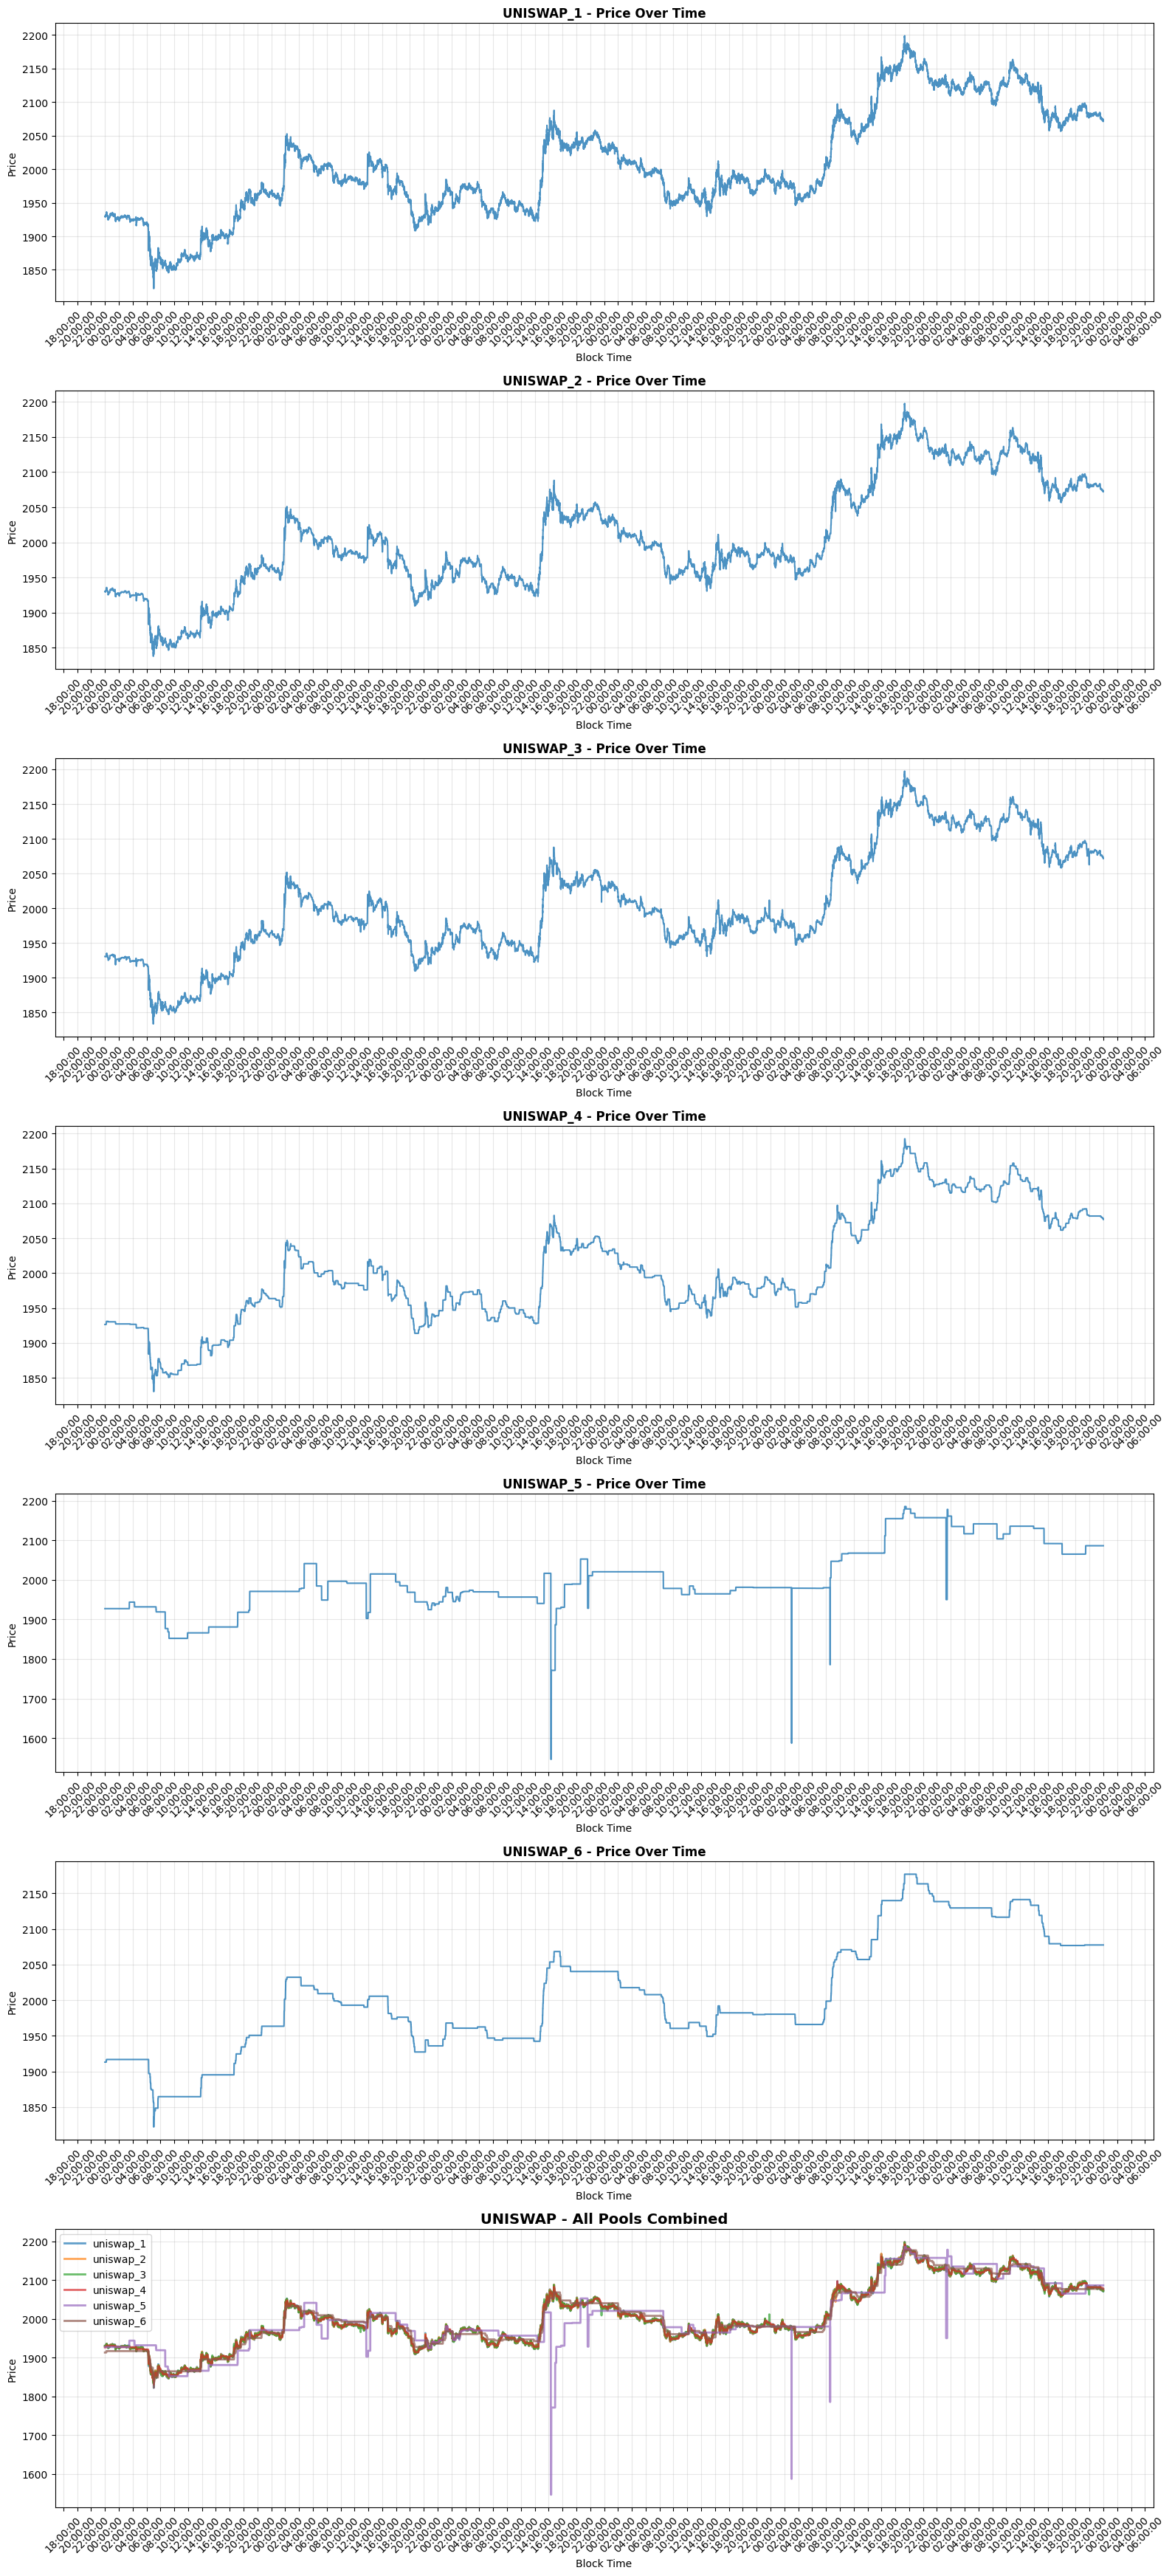


Plotted 6 uniswap pools + 1 combined view
  uniswap_1: 42995 blocks
  uniswap_2: 42995 blocks
  uniswap_3: 42995 blocks
  uniswap_4: 42995 blocks
  uniswap_5: 42995 blocks
  uniswap_6: 42995 blocks


In [2]:
plotting.plot_dex_pools(pools, dex="uniswap")

In [3]:
price_differences, all_price_differences = analysis.compute_pairwise_differences(pools)

DEXes found: ['uniswap', 'pancake']
Pools per DEX: [('uniswap', 6), ('pancake', 2)]

Computed 12 pairwise comparisons:

uniswap_1_vs_pancake_1:
  Rows: 42995
  Max diff: 35.679614
  Mean diff: 0.839642
  Min diff: 0.000079

uniswap_1_vs_pancake_2:
  Rows: 42995
  Max diff: 31.540124
  Mean diff: 0.858350
  Min diff: 0.000000

uniswap_2_vs_pancake_1:
  Rows: 42995
  Max diff: 35.611496
  Mean diff: 0.516133
  Min diff: 0.000000

uniswap_2_vs_pancake_2:
  Rows: 42995
  Max diff: 26.532024
  Mean diff: 0.752800
  Min diff: 0.000022

uniswap_3_vs_pancake_1:
  Rows: 42995
  Max diff: 37.372192
  Mean diff: 0.965994
  Min diff: 0.000000

uniswap_3_vs_pancake_2:
  Rows: 42995
  Max diff: 32.262873
  Mean diff: 1.151439
  Min diff: 0.000166

uniswap_4_vs_pancake_1:
  Rows: 42995
  Max diff: 40.455381
  Mean diff: 2.767477
  Min diff: 0.000590

uniswap_4_vs_pancake_2:
  Rows: 42995
  Max diff: 26.096121
  Mean diff: 2.782479
  Min diff: 0.000140

uniswap_5_vs_pancake_1:
  Rows: 42995
  Max diff

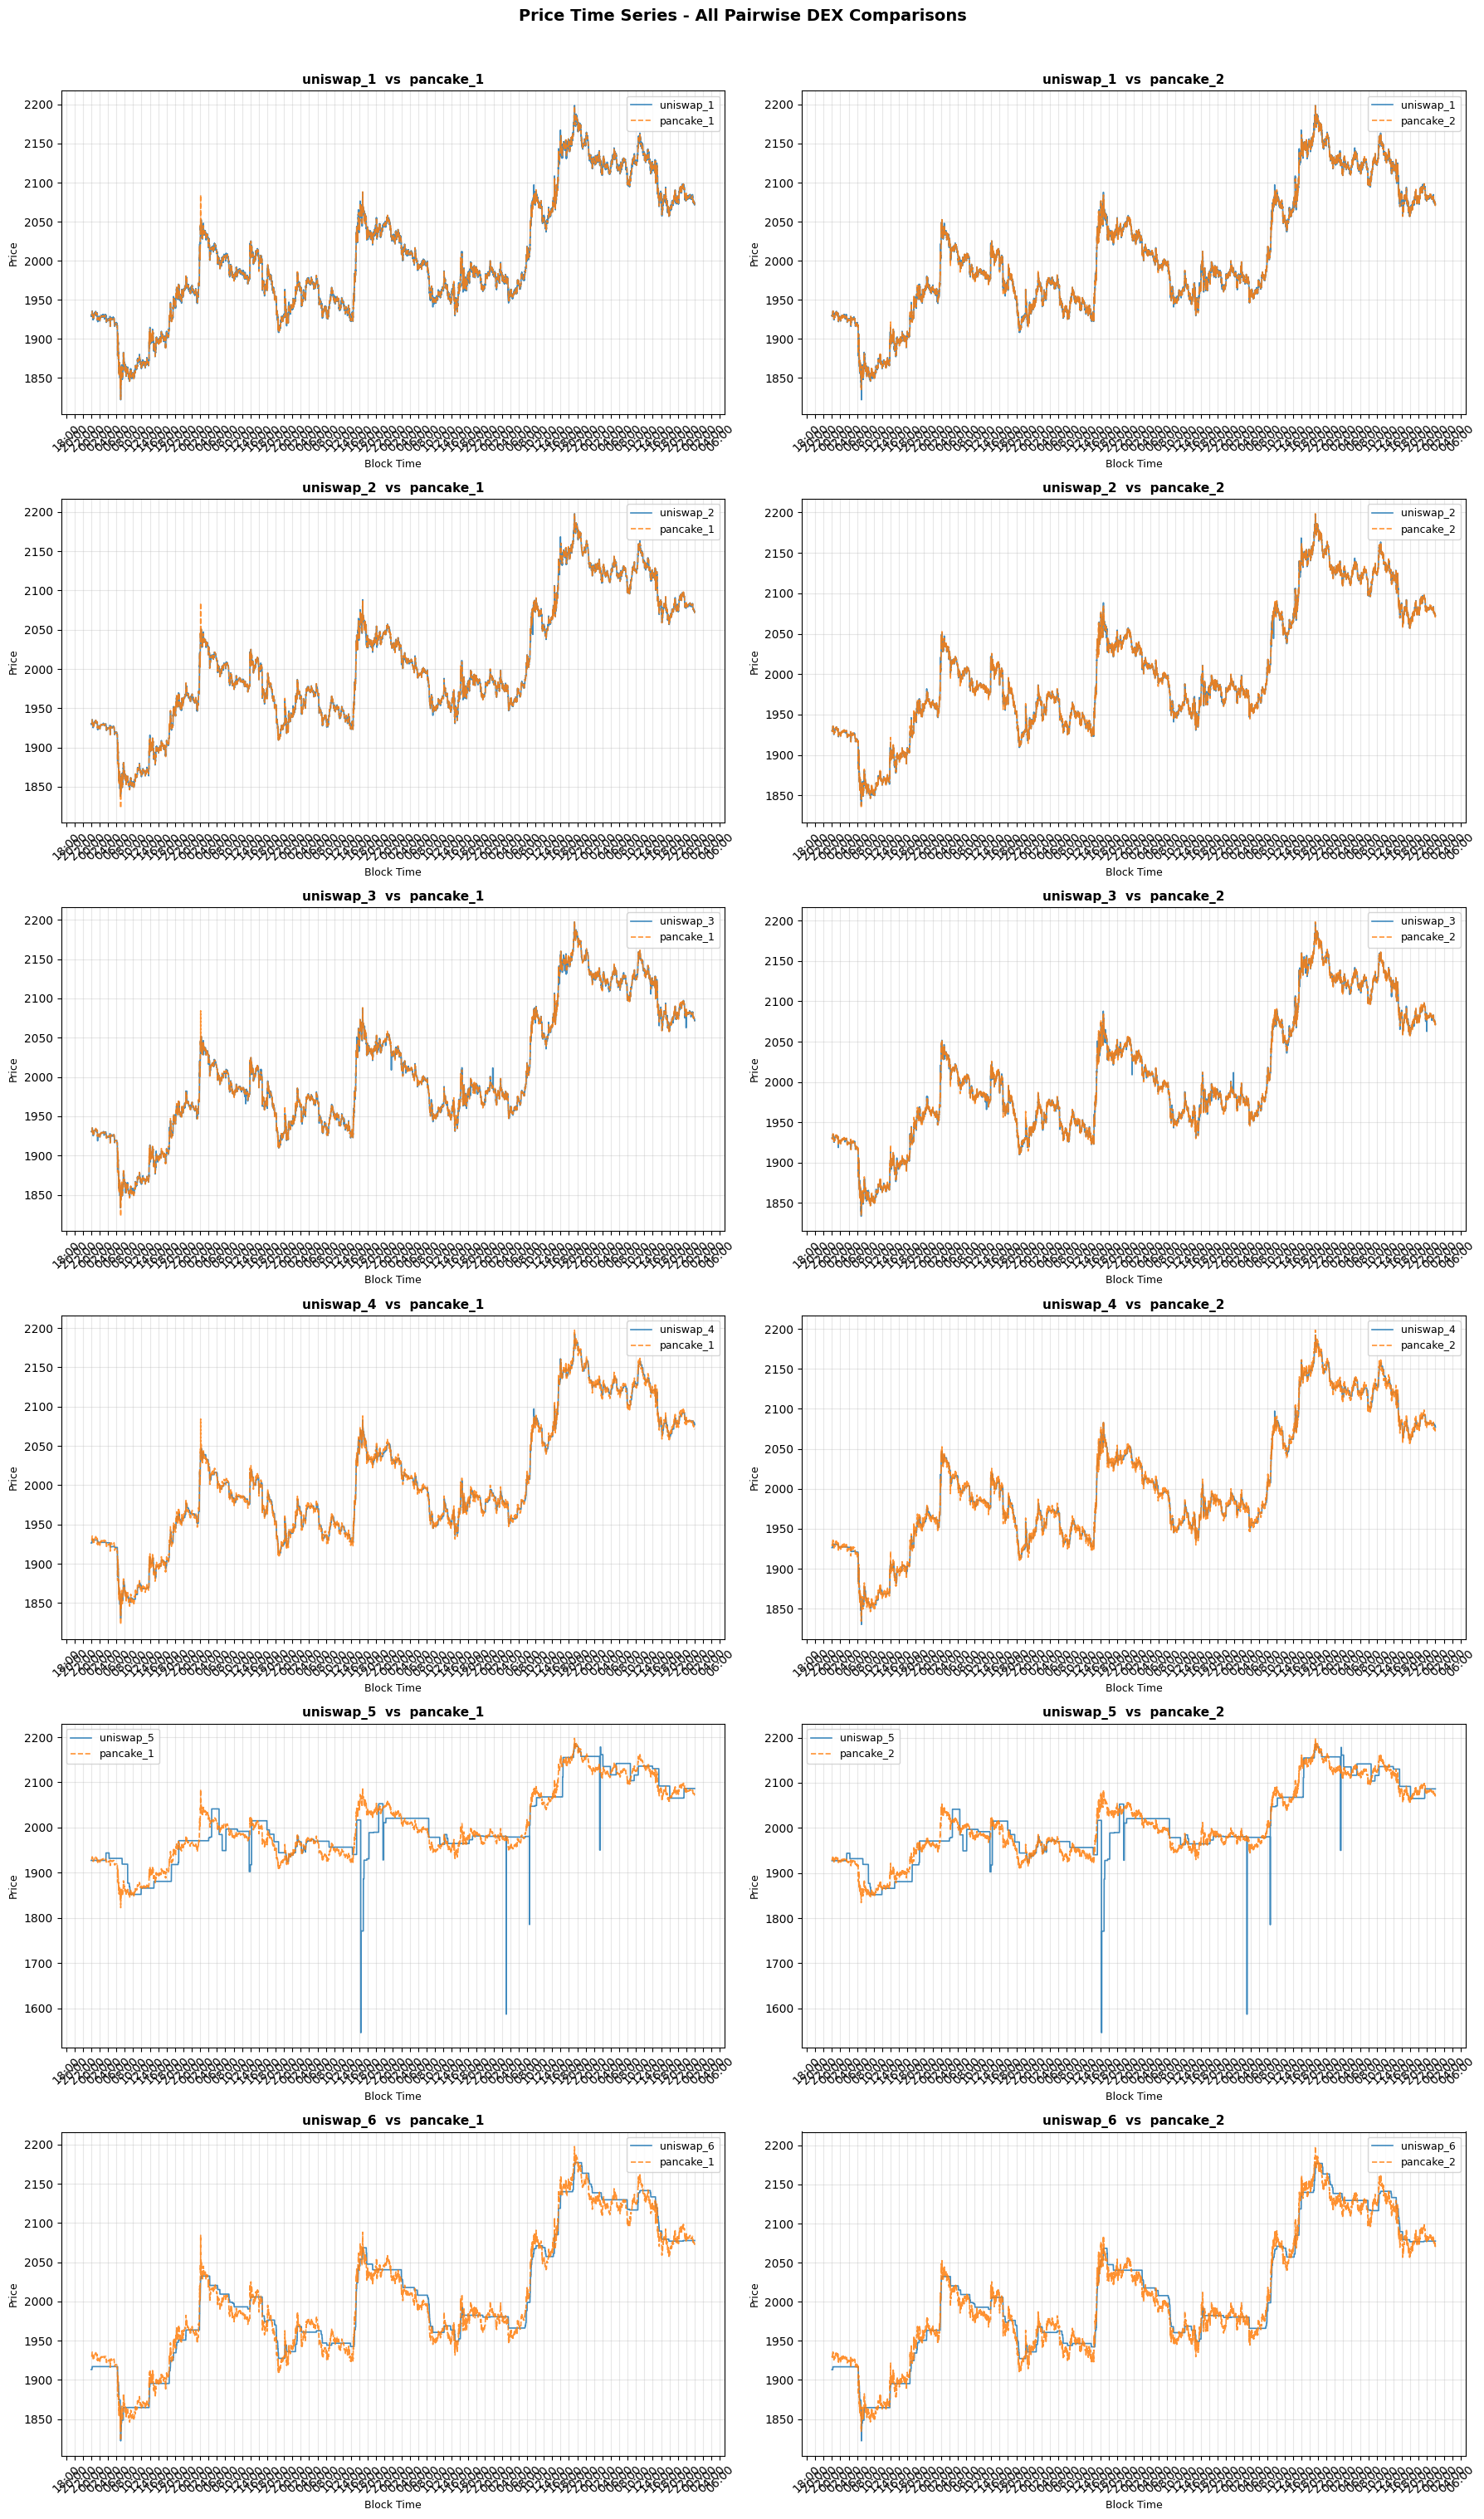

In [4]:
plotting.plot_pairwise_prices(price_differences)

## 2. Pick a pool pair

Bundle two pools' per-block state + market context into a `PoolPair`.

In [5]:
pair = arbitrage.build_pool_pair(
    pools["pancake_1"], pools["uniswap_1"], S.token0, S.token1, price0, price1, "pancake_1", "uniswap_1"
)

## 3a. Round-trip spreads at each reference trade size

Two panels per size (direction 1→2 and 2→1, Y- and X-anchored). A series below
zero is a profitable round trip after both fees + slippage.

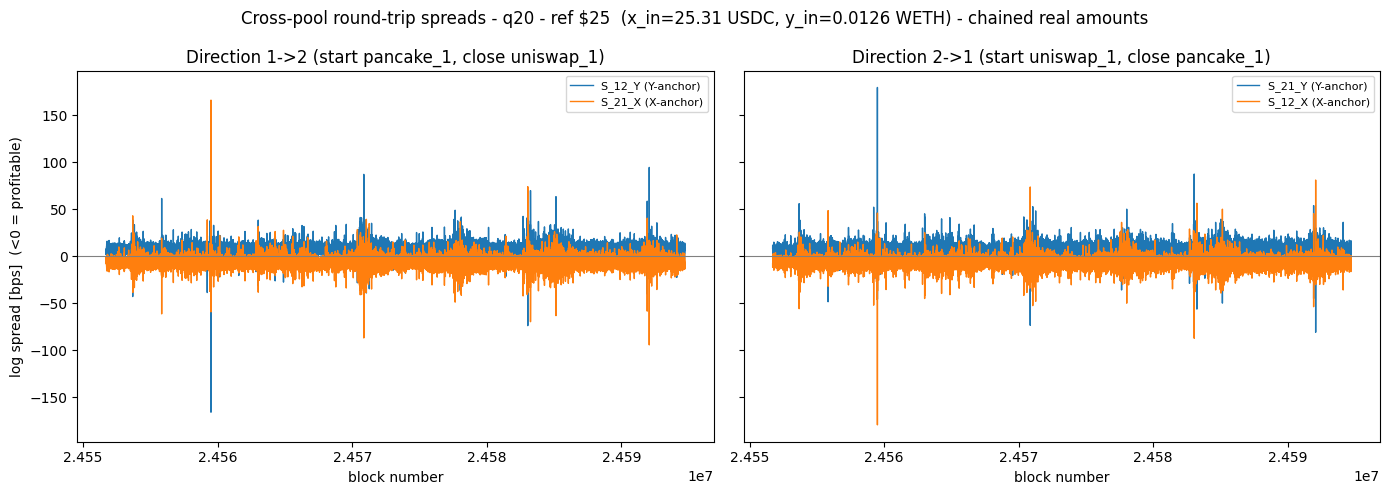

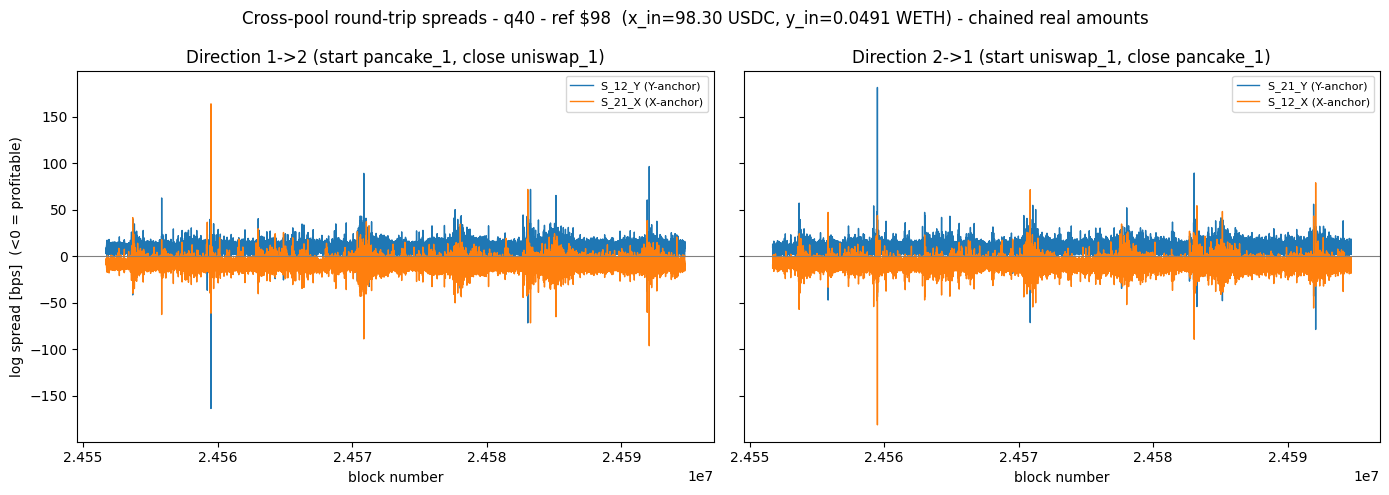

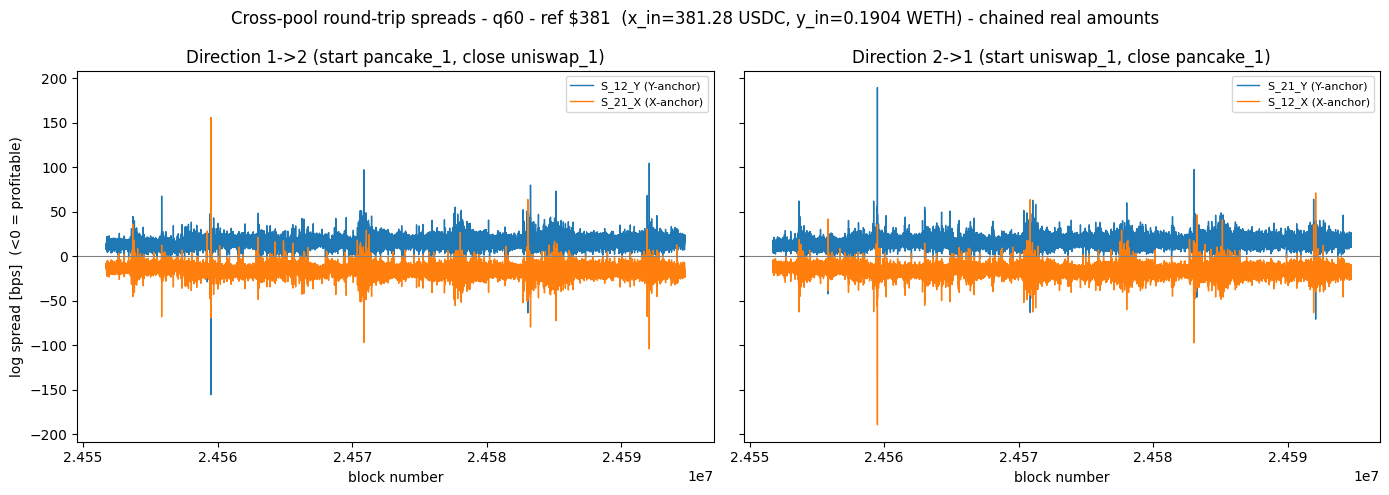

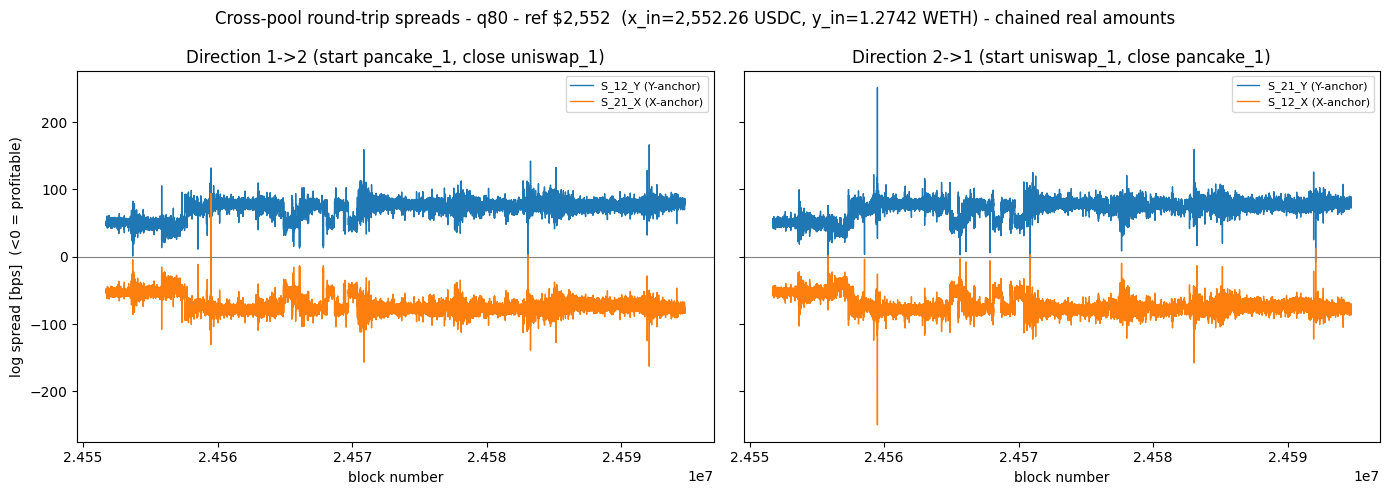

In [6]:
for q, Q in quantiles.items():
    plotting.plot_directional_spreads(pair, Q, f"Cross-pool round-trip spreads - q{int(q * 100)}")

## 3b. Custom trade size

Pass exactly one of `usd_amount` / `x_amount` (token0) / `y_amount` (token1).

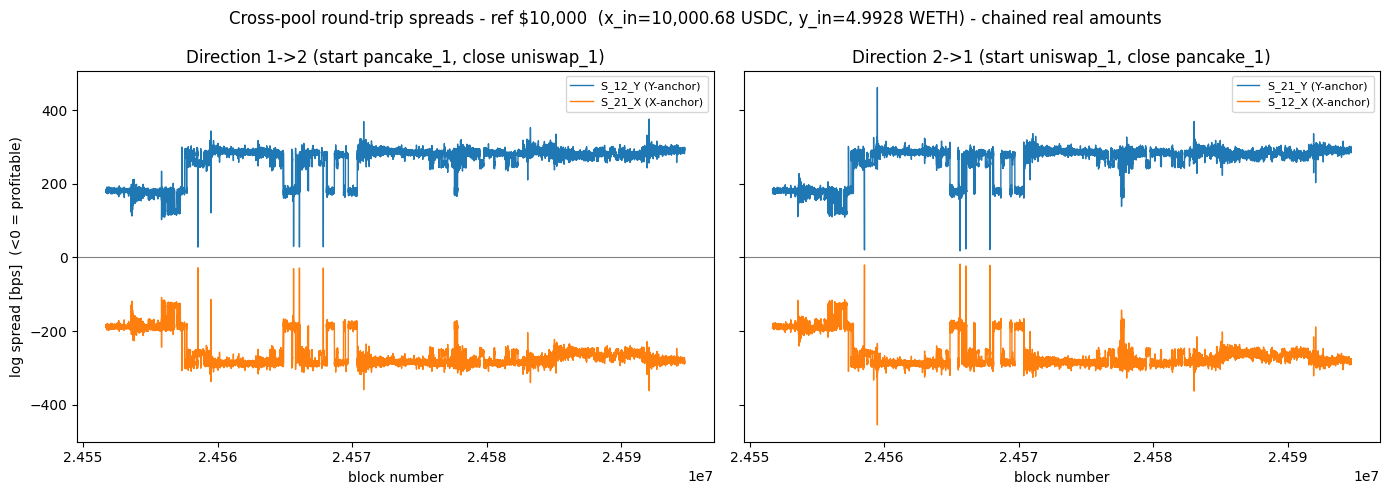

In [7]:
plotting.plot_custom_size(pair, usd_amount=10_000, title_prefix="Cross-pool round-trip spreads")

## 4. Arbitrage index (all pool pairs)

`all_pairs_gap_series` stores the per-block round-trip gap `Gap_t` (bps) for **every**
pool pair — intra-DEX (e.g. `uniswap_1_vs_uniswap_5`) as well as cross-DEX.
`arb_index["<poolA>_vs_<poolB>"]` is a blocks × trade-sizes frame; `arbitrage_index`
below summarises one pair across blocks.

In [8]:
arb_index = arbitrage.all_pairs_gap_series(pools, quantiles, S.token0, S.token1, price0, price1)
print("pairs:", list(arb_index))




pairs: ['uniswap_1_vs_uniswap_2', 'uniswap_1_vs_uniswap_3', 'uniswap_1_vs_uniswap_4', 'uniswap_1_vs_uniswap_5', 'uniswap_1_vs_uniswap_6', 'uniswap_1_vs_pancake_1', 'uniswap_1_vs_pancake_2', 'uniswap_2_vs_uniswap_3', 'uniswap_2_vs_uniswap_4', 'uniswap_2_vs_uniswap_5', 'uniswap_2_vs_uniswap_6', 'uniswap_2_vs_pancake_1', 'uniswap_2_vs_pancake_2', 'uniswap_3_vs_uniswap_4', 'uniswap_3_vs_uniswap_5', 'uniswap_3_vs_uniswap_6', 'uniswap_3_vs_pancake_1', 'uniswap_3_vs_pancake_2', 'uniswap_4_vs_uniswap_5', 'uniswap_4_vs_uniswap_6', 'uniswap_4_vs_pancake_1', 'uniswap_4_vs_pancake_2', 'uniswap_5_vs_uniswap_6', 'uniswap_5_vs_pancake_1', 'uniswap_5_vs_pancake_2', 'uniswap_6_vs_pancake_1', 'uniswap_6_vs_pancake_2', 'pancake_1_vs_pancake_2']


In [9]:
counts_02 = {
    pair: (df[0.2] > 0).sum()
    for pair, df in arb_index.items()
}

counts_02

{'uniswap_1_vs_uniswap_2': np.int64(2385),
 'uniswap_1_vs_uniswap_3': np.int64(10588),
 'uniswap_1_vs_uniswap_4': np.int64(245),
 'uniswap_1_vs_uniswap_5': np.int64(167),
 'uniswap_1_vs_uniswap_6': np.int64(298),
 'uniswap_1_vs_pancake_1': np.int64(7214),
 'uniswap_1_vs_pancake_2': np.int64(16650),
 'uniswap_2_vs_uniswap_3': np.int64(3075),
 'uniswap_2_vs_uniswap_4': np.int64(23),
 'uniswap_2_vs_uniswap_5': np.int64(115),
 'uniswap_2_vs_uniswap_6': np.int64(87),
 'uniswap_2_vs_pancake_1': np.int64(1074),
 'uniswap_2_vs_pancake_2': np.int64(3963),
 'uniswap_3_vs_uniswap_4': np.int64(170),
 'uniswap_3_vs_uniswap_5': np.int64(59),
 'uniswap_3_vs_uniswap_6': np.int64(51),
 'uniswap_3_vs_pancake_1': np.int64(2314),
 'uniswap_3_vs_pancake_2': np.int64(5597),
 'uniswap_4_vs_uniswap_5': np.int64(0),
 'uniswap_4_vs_uniswap_6': np.int64(2),
 'uniswap_4_vs_pancake_1': np.int64(57),
 'uniswap_4_vs_pancake_2': np.int64(232),
 'uniswap_5_vs_uniswap_6': np.int64(0),
 'uniswap_5_vs_pancake_1': np.int6

In [10]:
arbitrage.arbitrage_index(pair, quantiles)

,usd_ref,n_blocks,live_gap_share,mean_gap_bps,median_gap_bps,max_gap_bps,anchor_agreement
quantile,,,,,,,
0.2,25.305772,42995,0.167787,0.568362,0.0,165.944180,0.999395
0.4,98.297823,42995,0.087219,0.339330,0.0,163.864888,0.999023
0.6,381.251111,42995,0.013513,0.075560,0.0,155.808611,0.999512
0.8,2552.089436,42995,0.000116,0.002704,0.0,94.215229,1.000000


In [11]:
# keep only pool pairs with >=1 arbitrage event at the smallest size (q0.2); drop the rest so the
# modeling parquets (dependent variable + pair covariates) never contain empty pairs
kept_pairs = [pair for pair, n in counts_02.items() if n > 0]
dropped_pairs = [pair for pair, n in counts_02.items() if n == 0]
arb_index = {pair: arb_index[pair] for pair in kept_pairs}
print(f"kept {len(kept_pairs)} pairs with >=1 event; dropped {len(dropped_pairs)}: {dropped_pairs}")

kept 26 pairs with >=1 event; dropped 2: ['uniswap_4_vs_uniswap_5', 'uniswap_5_vs_uniswap_6']


## 5. Any arbitrage in the sample?

Heatmap of the round-trip gap across all pairs and blocks, one panel per reference
trade size. Coloured cells are profitable round trips (after fees + slippage); a
near-blank map means little arbitrage at that size.

q20: 58381 live (pair, block) cells of 1117870 | max gap = 167.71 bps


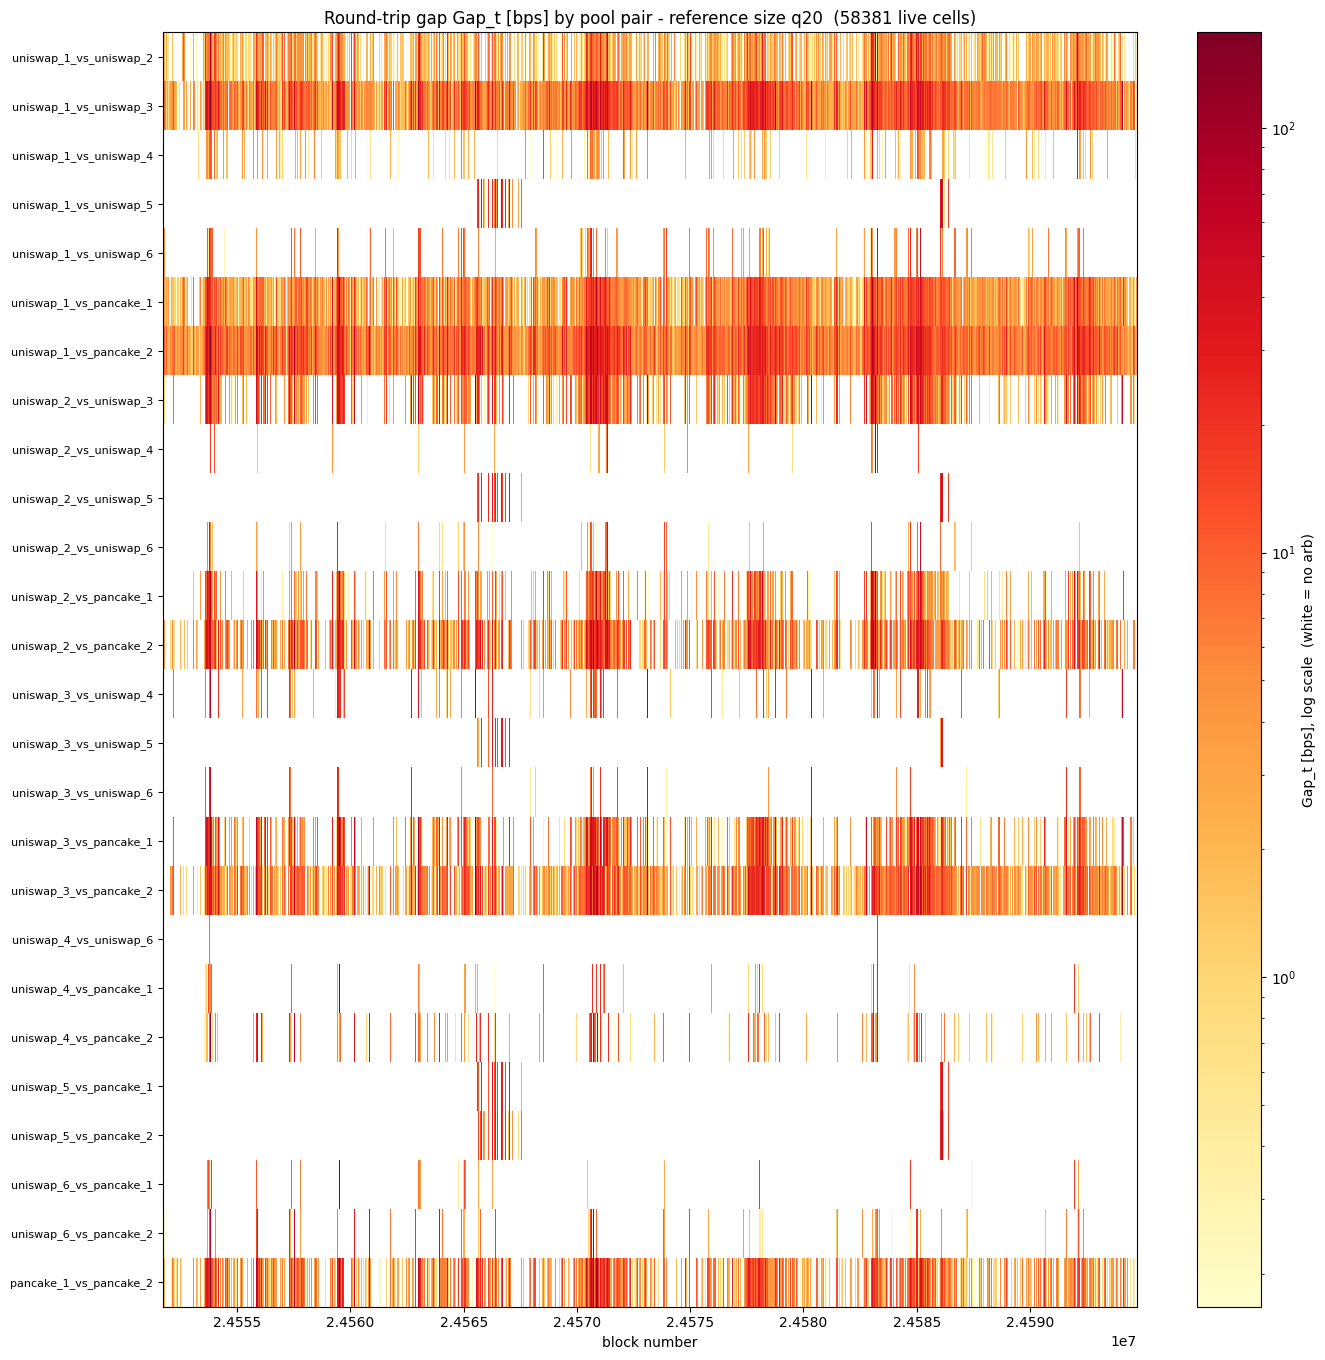

q40: 18009 live (pair, block) cells of 1117870 | max gap = 163.86 bps


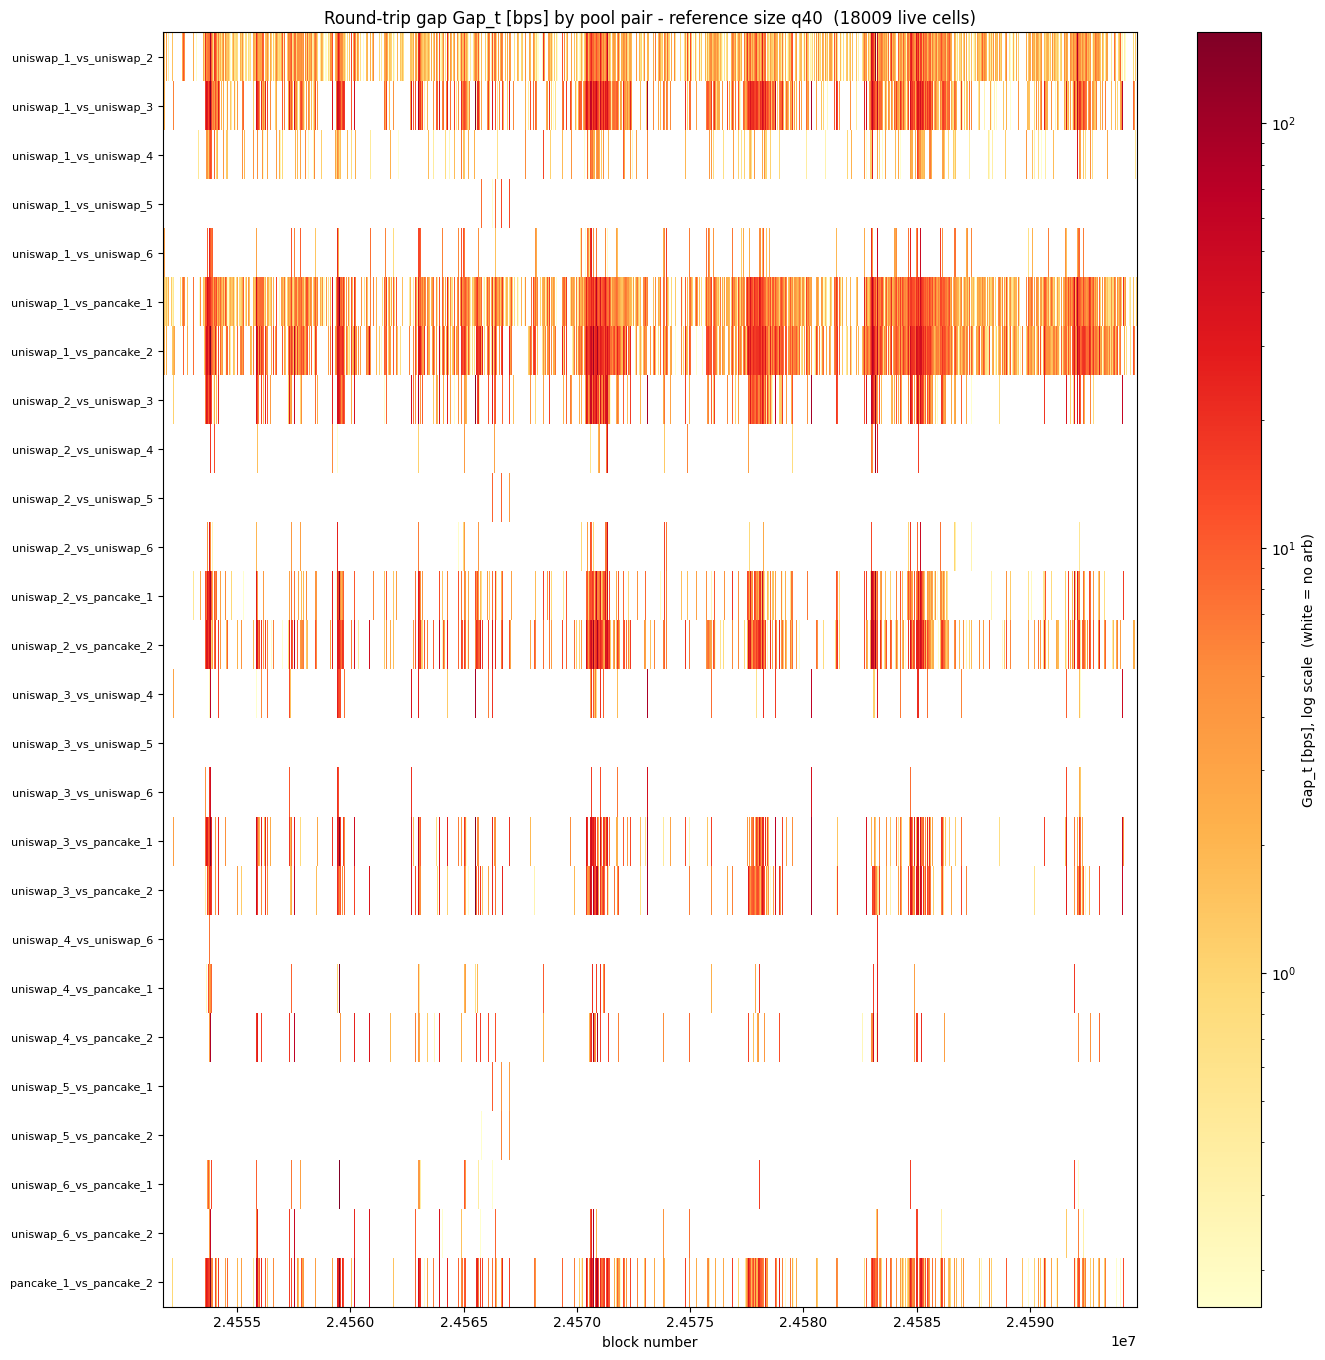

q60: 3247 live (pair, block) cells of 1117870 | max gap = 155.81 bps


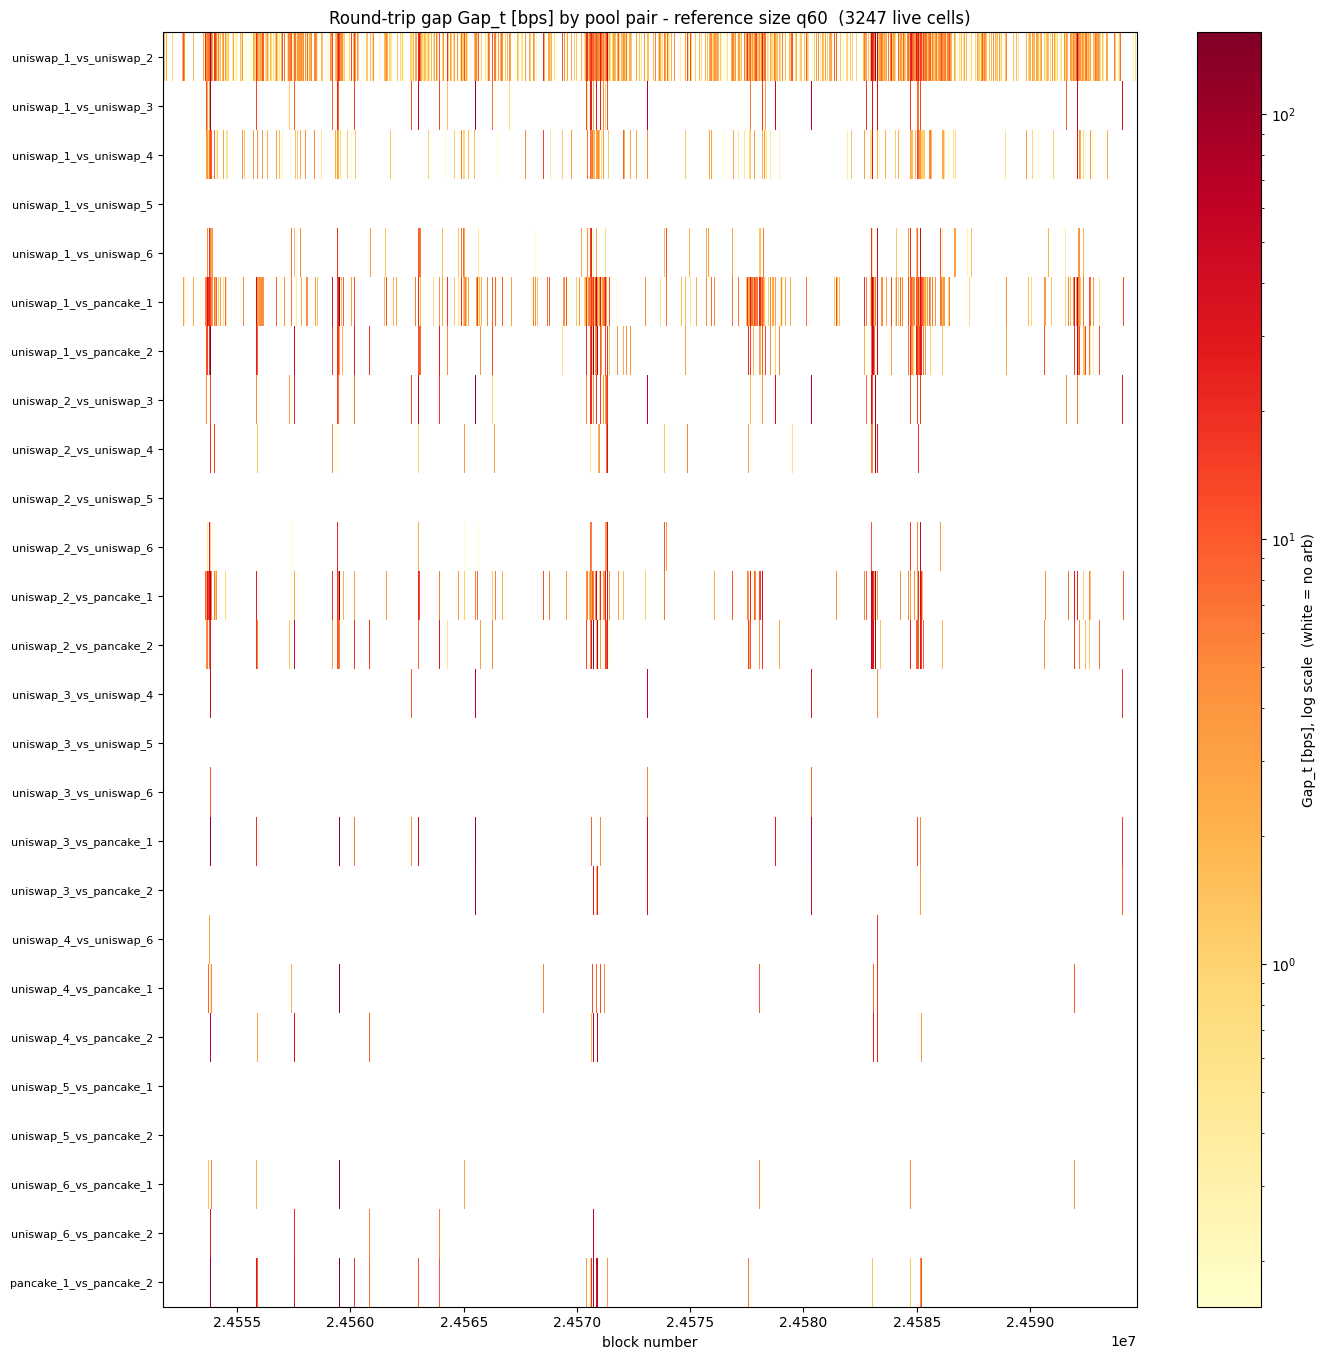

q80: 373 live (pair, block) cells of 1117870 | max gap = 125.91 bps


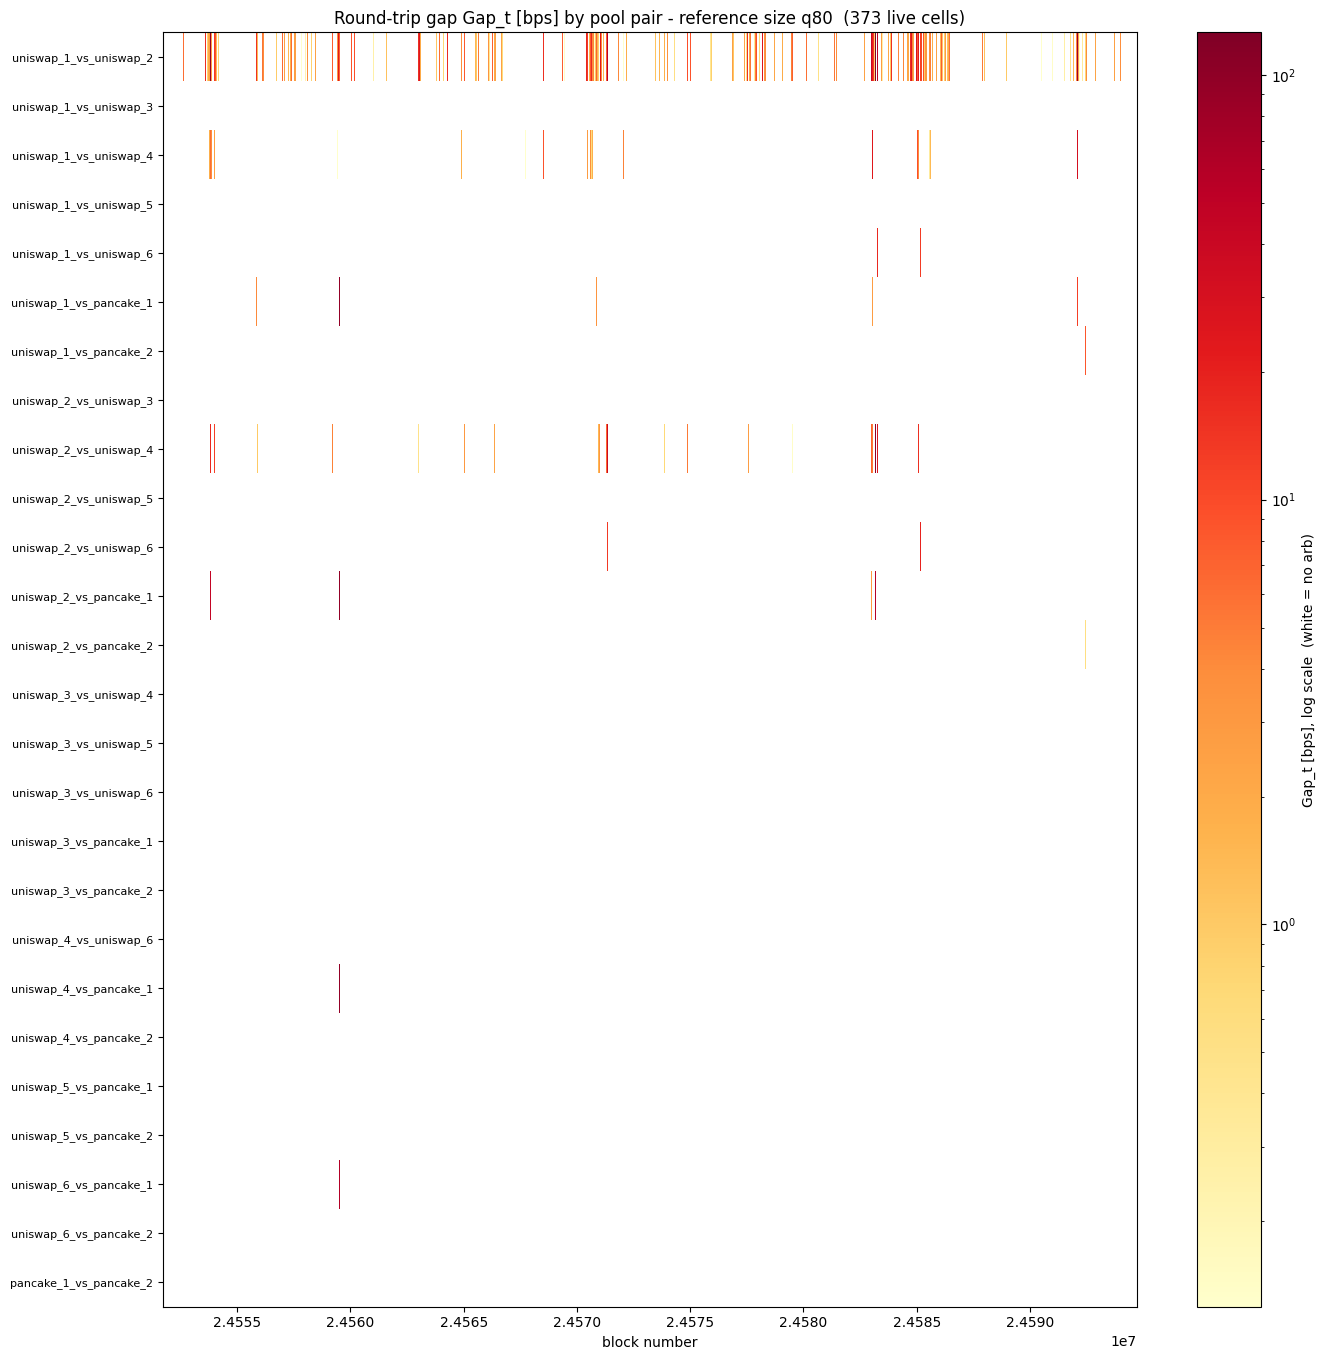

In [12]:
for q in quantiles.index:
    plotting.plot_arb_index(arb_index, q)

## 6. How long does arbitrage hold?

For each pool pair the arbitrage index is live (`Gap_t > 0`) in runs of consecutive
blocks — an arbitrage *spell*. `arb_hold_durations` extracts every spell's length (in
blocks); `plot_arb_durations` draws, **one graph per trade size**, the per-pair duration
**sequence** (x = spell index in order of occurrence, y = duration), e.g. `2, 6, 5, 4, …` —
one line per pool pair, a line's length being that pair's number of spells.

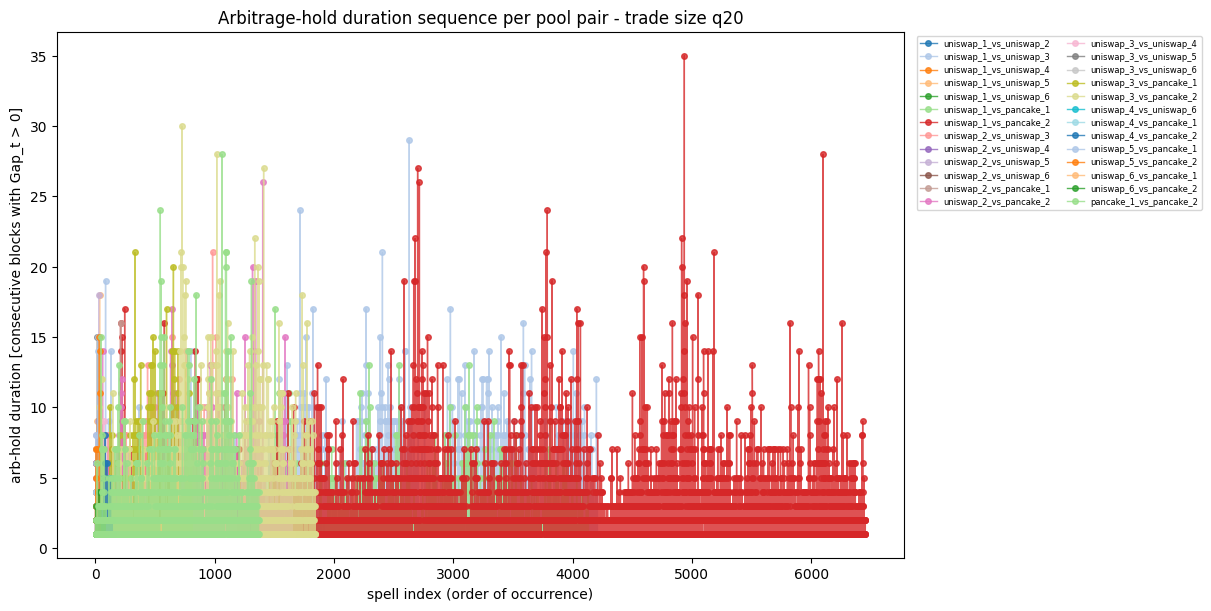

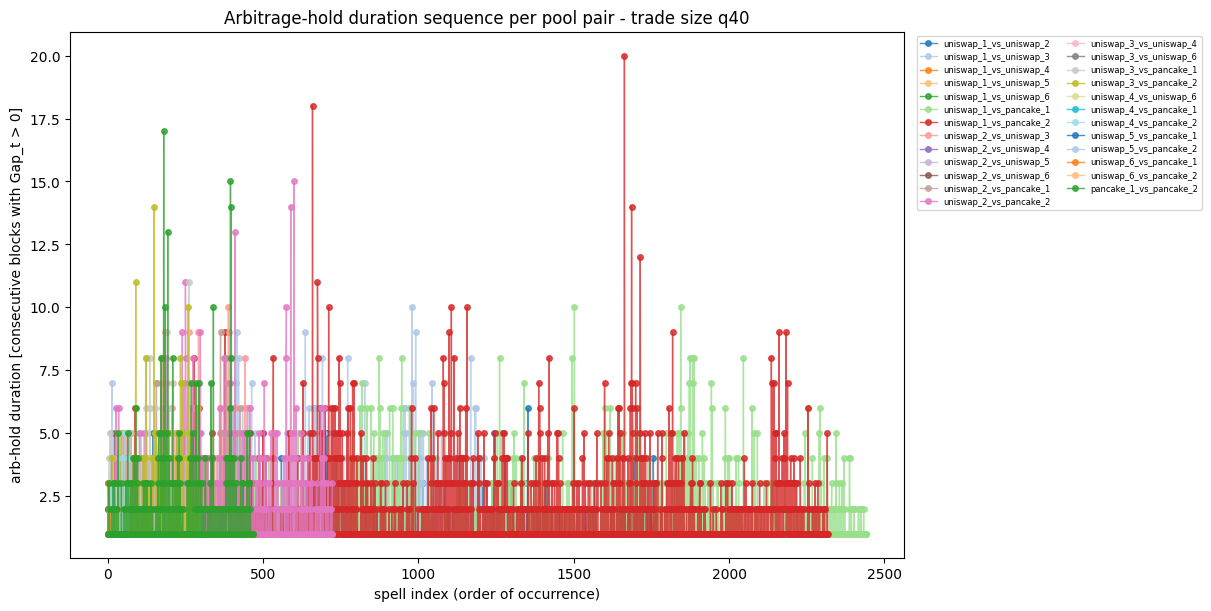

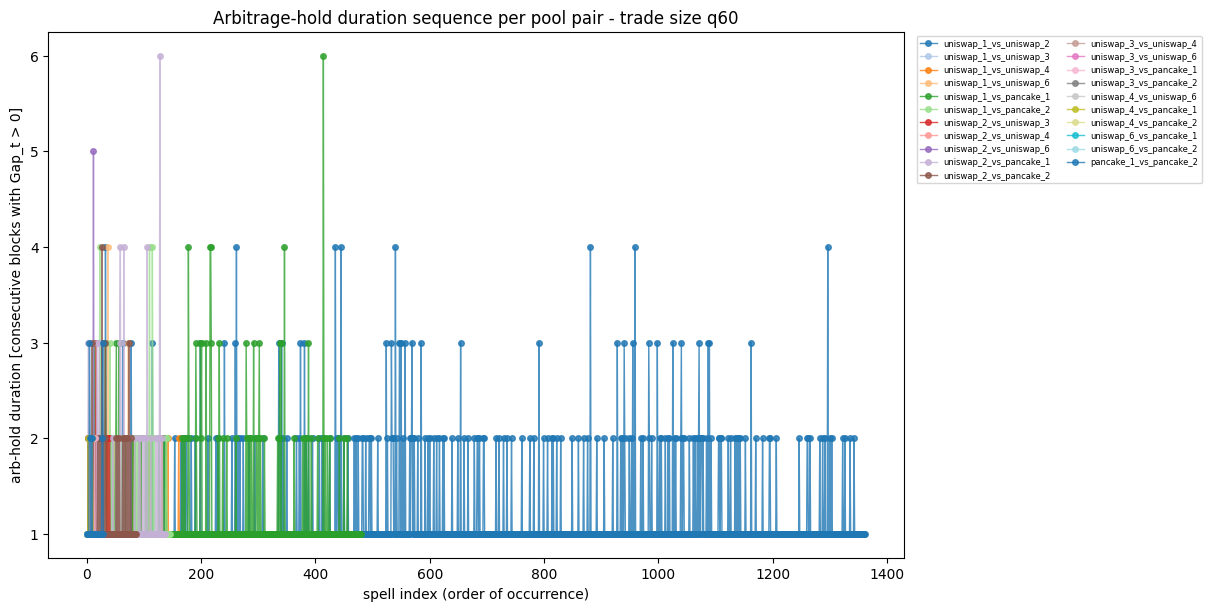

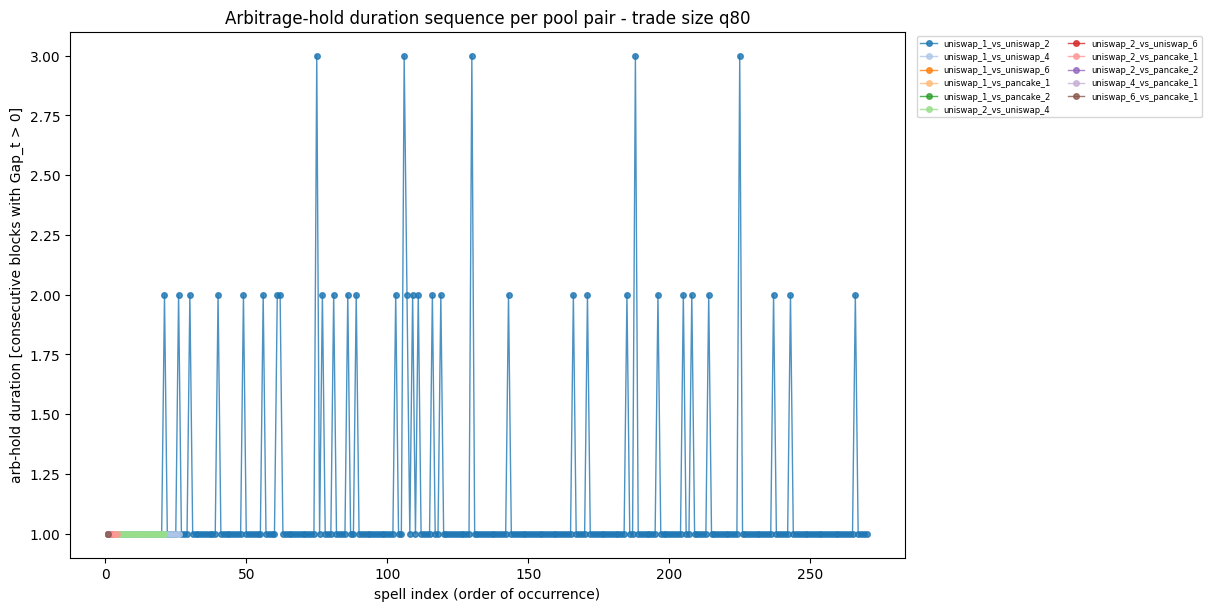

In [13]:
durations = arbitrage.arb_hold_durations(arb_index)
for q in quantiles.index:
    plotting.plot_arb_durations(durations, q)

## 7. Save the dependent variable (one parquet per pool pair)

For every pool pair, persist the panel dependent variable to
`S.dependent_var_dir` (`modeling/dependant_variable/<pair>.parquet`): the continuous
round-trip gap `Gap_t(Q)` (bps) and its binary existence `D_t(Q) = 1[Gap_t(Q) > 0]`
for each reference quantile, keyed by `blocknumber` / `evt_block_time`. Gap is kept
alongside `D` so the same column feeds both the outcome and its own lag downstream.

In [14]:
modeling.save_dependent_variables(arb_index, pools, S.dependent_var_dir)

Saved 26 dependent-variable parquet files to /Users/matthieu/Downloads/DeFi_limits-to-arbitrage/ethereum/WETH_USDC/high_vol/modeling/dependant_variable


## 8. Save the pool-pair covariates (one parquet per pool pair)

For every pool pair, persist the venue-averaged, pool-pair-dependent covariates to
`S.pair_covariates_dir` (`modeling/covariates/pool_pair_dependant_covariates/<pair>.parquet`):
`mev_intensity` = ½(log(1+mev¹)+log(1+mev²)) and `frequency_intensity` = ½(ewma¹+ewma²).
Both contemporaneous at block t, keyed by `evt_block_number` / `evt_block_time` — same pair
names as the dependent variable, so the two join 1:1. Lag by one block downstream to make them
predetermined.

In [15]:
modeling.save_pair_covariates(pools, S.pair_covariates_dir, keep_pairs=list(arb_index))

Saved 26 pool-pair covariate parquet files to /Users/matthieu/Downloads/DeFi_limits-to-arbitrage/ethereum/WETH_USDC/high_vol/modeling/covariates/pool_pair_dependant_covariates
